# FE621 HW2

Cian Gahan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from FE621.pricing.tree import BinomialTree, TrinomialTree
from FE621.pricing.black_scholes import BlackScholes

## Problem 1: The Binomial Tree

a) Construct code to calculate option values using an additive binomial tree.
For this part you need four versions: European and American as well as
Call and Put. You may use the same tree construction (and function) for
all options.

- See ```src/FE621/pricing/tree.py``` for binomial tree implementation

b) Download Option prices (you can use the Bloomberg Terminal, Yahoo! Finance,
etc.) for an equity, for 3 different maturities (1 month, 2 months, and
3 months) and 20 strike prices close to the value at the money. If 3 months
does not exist use next one available. Please download the data DURING
THE TRADING DAY (9:00am to 4:30pm ET). Otherwise your values will
be way off. Do not forget to download the value of the underlying. For
each strike price in the data, use the implied vol values in Homework 1 (see
Problem 1c) and the current short-term interest rate (the Feds Fund rate
is a good choice). Calculate the option price (European Calls and Puts)
using the binomial tree, and compare the results with the Black–Scholes
price. Use at least 200 steps in your tree construction. Treat the options as
American as well and plot these values side by side with the European and
Black Scholes values. When you create the plot do not forget to plot the
bid-ask values as well. If you downloaded DATA 2 for last assignment you
can use that as your data set.

c) Comment of the table in the previous part.

d) Consider $N \in \{10, 20, 30, 40, 50, 100, 150, 200, 250, 300, 350, 400\}$. Compute and plot the absolute error for the European Put $\epsilon_N$ as a function of $N \in \mathbb{N}*$ the number of steps in the tree:

$$
\epsilon_N = |P^{BSM}(S_0,K,T,r;\sigma) - P^{BinomTree}(S_0,K,T,r;\sigma)|
$$

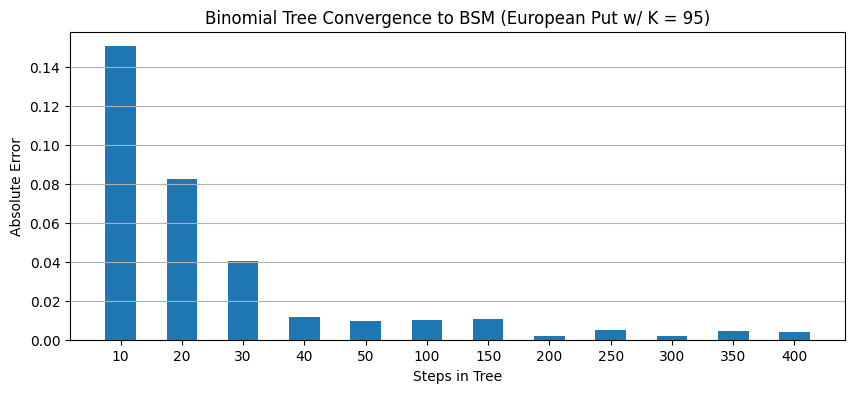

In [2]:
ns = [10, 20, 30, 40, 50, 100, 150, 200, 250, 300, 350, 400]

s0 = 100
K = 95
T = 1
r = 0.05
sigma = 0.2

bsm_price = BlackScholes.put(s0, K, T, r, sigma)
errors = []

for n in ns:
    tree = BinomialTree(r, sigma, s0, T, n)
    errors.append(abs(tree.price_option(K, call=False, american=False) - bsm_price))

plt.figure(figsize=(10,4))
plt.bar(range(len(ns)), errors, width=0.5)
plt.xticks(range(len(ns)), labels=ns)
plt.grid(visible=True, axis="y")
plt.xlabel("Steps in Tree")
plt.ylabel("Absolute Error")
plt.title("Binomial Tree Convergence to BSM (European Put w/ K = 95)")
plt.show()

## Problem 2: Pricing Exotic Options using Trinomial Trees

We will use here a synthetic example to illustrate using trees to price path
dependent options.

a) Construct a trinomial tree to calculate the price of an European Up-and-Out
call option. Use S0 = 10, strike K = 10, maturity T = 0.3, volatility $\sigma$ = 0.2,
short rate r = 0.01, dividends $\delta$ = 0 and barrier H = 11. See Chapter 3
in [1] for the trinomial tree construction. Use as many steps in your tree
as you think are necessary. Hint. For the option pricing you may consult
the algorithm in the book [1] and try and figure out how to modify the code
there to work with the new option and the new tree. Note the book details
the computation using a binomial tree while we ask you to use a trinomial
tree here.

- See ```src/FE621/pricing/tree.py``` for Trinomial tree implementation

In [3]:
s0 = 10
K = 10
T = 0.3
sigma = 0.2
r = 0.01
H = 11

# Using 300 steps to keep order of convergence low (∆t = 0.001)
trinom_tree = TrinomialTree(r, sigma, s0, T, n=300)
up_out_call_price = trinom_tree.price_barrier_option_knock_out(K, H, call=True)
print(up_out_call_price)

0.05831284403967179


b) For the European Up-and-Out Call option explicit formulas exist. For example, implement the formula (5.2) from [2] and compare your results with part (a). Use the same parameters as before. Are your results matching? Note
the paper is uploaded to the course shell under the name “Pricing Barrier
Options”

- See ```src/FE621/pricing/black_scholes.py``` for explicit formula implementation

In [4]:
print(BlackScholes.up_out_call(s0, K, H, T, r, sigma))

0.05309279660325303


The price is quite close but slightly lower than the tree approximation. This seems plausible given the order of convergence above is proportional to the actual error by an unknown constant (in this case an error of around 0.005).

c) Price an European Up-and-In call option, using the same parameters as
before. Hint. Two methods can be employed: the analytical solution in
(5.1) or the In-Out parity. Use both methods in order to verify your results.

- See ```src/FE621/pricing/tree.py``` for trinomial tree knock-in barrier option pricing implementation

In [6]:
print("Analytical/Tree-Based:", trinom_tree.price_barrier_option_knock_in(K, H, call=True, american=False))
print("In/Out Parity:", trinom_tree.price_option(K, call=True, american=False) - up_out_call_price)

Analytical/Tree-Based: 0.3926115418733819
In/Out Parity: 0.3926115418733819


d) Calculate the price of an AMERICAN Up and In Put option

- This is implemented identically to the european knock-in option inside ```src/FE621/pricing/tree.py```, except within the hit state tree the node values are calculated with the possibility of early exercise

In [9]:
print(trinom_tree.price_barrier_option_knock_in(K, H, call=False, american=True))

0.015251201994063806


## Problem 3: Finite difference methods.

a) Implement the Explicit Finite Difference method to price both European
Call and Put options. Hint. See Chapter 3 in [1].

b) Implement the Implicit Finite Difference method to price European Call
and Put options.

c) Implement the Crank-Nicolson Finite Difference method and price both
European Call and Put options.

d) For both the Explicit and Implicit Finite Difference schemes estimate the
numbers $\Delta t$, $\Delta x$ as well as the total number $N_j$ of points on the space grid
x to obtain a desired error of $\epsilon = 0.001$. Hint. You need to solve this part in a
theoretical way. Please use the convergence order as the actual error of the
estimate.

Starting with Explicit FD: The order of convergence (treated in this case as the error) is $\epsilon = {\Delta x}^2 + \Delta t$.

Since $\Delta x = \sigma \sqrt{3 \Delta t}$, $\epsilon = \Delta t (1 + 3 \sigma^2) = 0.001$

Therefore $\Delta t = \frac{0.001}{1 + 3 \sigma^2}$, so the space grid width $N = 1000T + 3000T \sigma^2$

Total points on the grid (that are used, the size of the 2d array would be $N(2N + 1)$) is $N^2 = 1,000,000T^2 + 6,000,000T \sigma^2 + 9,000,000 \sigma^4 $

e) Consider S0 = 100, K = 100, T = 1 year, $\sigma = 25%$, r = 6%, $\delta = 0.03$.
Calculate and report the price for European Call and Put using explicit,
implicit FD and Crank-Nicolson methods and the number of steps that you
calculated in the previous point (part d).

f) Repeat part (d) of this problem but this time get the empirical number of
iterations. Specifically, obtain the Black Scholes price for the data in (e),
then do an iterative procedure to figure out the $\Delta x$, $\Delta t$, N , and Nj to
obtain an accuracy of $\epsilon = 0.001$. Put the results of the 3 methods (EFD,
IFD, CNFD) side by side in a table and write your observations.

### Bonus Problem 2: Pricing a Chooser Option. 

A Chooser option is a derivative product which gives the right to the holder to own at
maturity either a Put Option or a Call Option depending on the relationship of
the Stock price at maturity and the strike price K. In other words the option
payoff is determined as:

$$
\mathbb{E}[(S_T - K)_+ \mathbf{1}_{\{S_T \ge K\}} + (K - S_T)_+ \mathbf{1}_{\{S_T < K\}}]
$$

a) Develop a binomial tree model to price a chooser option on a stock with
exercise price $K = 100$, $S_0 = 100$, maturity $T = 0.3$, volatility $\sigma = 0.15$. Assume
a risk-free rate is $r = 0.01$.

- See ```src/FE621/pricing/tree.py``` for binomial tree pricing implementation (```BinomialTree.price_chooser_option```)

In [ ]:
chooser_tree = BinomialTree(r_f = 0.01, sigma=0.15, s0=100, T=0.3, n=100) # using 100 steps
print(chooser_tree.price_chooser_option(K=100, american=False))

6.531642686788443


b) Describe how an American type Chooser Option
would differ from the above Option. Extend your algorithm to approximate the
price of such an option.

Assuming the Chooser optionality extends backward as with early exercise, that is, one can choose to exercise the option early and choose which type (call/put) the payoff is selected from, this functions similarly to an American call or put, just with a different payoff diagram. The difference between this and the European version is the early exercise, but the functional payoff diagram of $|S_T - K|$ remains the same.

The ```price_chooser_option``` function above includes an ```american``` boolean flag which incorporates early exercise into the pricing:

In [ ]:
print(chooser_tree.price_chooser_option(K=100, american=True))

6.5500853673803165


We can see that the value of the option increases slightly when it becomes American, which makes sense as the option's put leg could plausibly create conditions where early exercise is optimal.